In [2]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

### Autonomous Vehicles Analysis

We will be doing exploratory data analysis on autonomous vehicle incidents using a public dataset. https://www.nhtsa.gov/laws-regulations/standing-general-order-crash-reporting#data

The goal of this analysis is to clean, preprocess and form a deeper understanding of the dataset. Then, if the exploratory data analysis has enough predictors, we'll use a classifier to determine if an incident will result in a fatal injury.

Due to scoping, we won't be preprocessing text data of the description of the incident. There may be opportunities to use NLP techniques for feature engineering

#### Overview

Vehicle automation are composed with 2 buckets and 5 levels:

ADAS: Advanced Driver Assistance Systems (SAE Levels: 0-2)

ADAS Levels 0-2 are systems that assist the driver but do not replace them:

level 0: no automation, level 1: driver assistance (e.g. adaptive cruise control), level 3: partial automation (Tesla Autopilot; steer and break but driver must be engaged)


ADS: Automated Driving System (SAE Levels: 3-5)

ADS Levels 3-5 are systems that perform the entire driving task under certain conditions without human intervention.

level 3: conditional automation(e.g. the system drives, but human must be ready to take over), level 4: high automation (no human intervention needed within a certain geofence), level 5: full automation (no human needed at all, anywhere

What is considered an incident?

​The National Highway Traffic Safety Administration (NHTSA) defines an incident involving Automated Driving Systems (ADS) through its Standing General Order (SGO) 2021-01. According to this order, a crash involving an ADS-equipped vehicle is reportable if the ADS was engaged at any time within 30 seconds before the crash and the crash resulted in property damage, injury, or fatality

#### Data Limitations

##### Misclassification

ADS crashes are categorized based on WHAT driving automation system was reported as being equipped, NOT what system was reported to be engaged at the time of incident.

A crash involving a level 2 ADAS system could be accidentally logged as ADS


##### Reporting Consistency




ADS-equipped use multiple sensors and cameras that have advanced data recording capabilities. These reports can be reported in a timely manner with attention to detail.

Level 2 ADAS equipped vehicles may be limited in their capabilities to record data related to driving automation systems. Furthermore, Level 2 ADAS equipped vehicles are privately owned and as a result do not report unless contacted by vehicle owner.

A reporting entity is required to submit an incident report within a certain timeframe regardless of whether the reporting entity has verified or agrees with the information.

The same crash may have multiple reports. For example, the vehicle manufacture, system developer/supplier and operator of the vehicle may all be named in the General Order. This  means that a single crash may have multiple reports from multiple entities.

Due to known limitations in the reporting process—such as the potential misclassification between ADS and Level 2 ADAS systems, and the possibility of duplicate records from multiple submissions for a single crash—this analysis does not include intensive data cleaning or deduplication procedures.

#### Data Dictionary

In [3]:
df = pd.read_csv('data/SGO-2021-01_Incident_Reports_ADS (1).csv')
df.shape

(1975, 137)

The dataset has 137 fields, I will choose features without using no robust feature selection methods. But based on how informative the feature is.

In [4]:
df_dictionary = {
    "report_id" : "A unique report number generated by NHTSA to track initial and updated reports for a given incident.",
    "reporting_entity" : "Name of the company filing the report",
    "make" : "vehicle manufacturer",
    "model" : "the model of the subject vehicle as branded",
    "model_year": "the year of the model",
    "mileage" : "mileage of the vehicle",
    "operator_type" : "driver / operator type",
    "state_or_local_permit" : "does the vehicle have a state permit",
    "ads_equipped?": "report of whether the vehicle equipped with ADS",
    "automation_system_engaged": "if ads/adas was used 30 seconds before incident",
    "incident_date" : "date of incident",
    "city" : "city of where vehicle incident happened",
    "state" : "state of where vehicle incident happened",
    "roadway_type": "type of road where the incident occurred",
    "roadway_surface": "surface condition of the road during the crash",
    "roadway_description": "description of any unusual road features (e.g., work zone)",
    "posted_speed_limit_mph": "posted speed limit at crash location",
    "lighting": "lighting condition at time of crash (e.g., daylight, dark)",
    "weather_clear": "whether the weather was clear",
    "weather_snow": "whether it was snowing",
    "weather_cloudy": "whether it was cloudy",
    "weather_fog_smoke": "whether fog or smoke was present",
    "weather_rain": "whether it was raining",
    "weather_severe_wind": "whether there were severe winds",
    "weather_unknown": "whether the weather was unknown",
    "weather_other": "indicator for any other weather condition",
    "weather_other_text": "text description of other weather conditions",
    "crash_with": "object or entity the vehicle collided with",
    "highest_injury_severity_alleged": "most severe injury reported or alleged",
    "property_damage": "whether property damage occurred",
    "cp_pre_crash_movement": "movement of the crash partner before the incident",
    "cp_airbags_deployed": "whether any airbags in crash partner deployed",
    "cp_vehicle_towed": "whether crash partner was towed",
    "cp_contact_rear_left": "contact on crash partner rear left",
    "cp_contact_left": "contact on crash partner left side",
    "cp_contact_front_left": "contact on crash partner front left",
    "cp_contact_rear": "contact on crash partner rear",
    "cp_contact_top": "contact on crash partner top",
    "cp_contact_front": "contact on crash partner front",
    "cp_contact_rear_right": "contact on crash partner rear right",
    "cp_contact_right": "contact on crash partner right side",
    "cp_contact_front_right": "contact on crash partner front right",
    "cp_contact_bottom": "contact on crash partner bottom",
    "cp_contact_unknown": "location of contact on crash partner is unknown",
    "sv_pre_crash_movement": "movement of the subject vehicle before crash",
    "sv_airbags_deployed": "whether airbags in the subject vehicle deployed",
    "sv_vehicle_towed": "whether subject vehicle was towed",
    "sv_all_passengers_belted": "whether all subject vehicle passengers wore seatbelts",
    "sv_precrash_speed_mph": "estimated pre-crash speed of the subject vehicle",
    "sv_contact_rear_left": "contact on subject vehicle rear left",
    "sv_contact_left": "contact on subject vehicle left side",
    "sv_contact_front_left": "contact on subject vehicle front left",
    "sv_contact_rear": "contact on subject vehicle rear",
    "sv_contact_top": "contact on subject vehicle top",
    "sv_contact_front": "contact on subject vehicle front",
    "sv_contact_rear_right": "contact on subject vehicle rear right",
    "sv_contact_right": "contact on subject vehicle right side",
    "sv_contact_front_right": "contact on subject vehicle front right",
    "sv_contact_bottom": "contact on subject vehicle bottom",
    "sv_contact_unknown": "location of contact on subject vehicle is unknown"
}


Parsed through the data dictionary chose fields that made sense to the analysis and basing the selection off of sparsity of data.

In [5]:
df

,Report ID,Report Version,Reporting Entity,Report Type,Report Month,Report Year,Report Submission Date,VIN,VIN - Unknown,Serial Number,...,Investigating Officer Name,Inv. Officer Name - Unknown,Investigating Officer Phone,Inv. Officer Phone - Unknown,Investigating Officer Email,Inv. Officer Email - Unknown,Within ODD?,Within ODD? - CBI,Narrative,Narrative - CBI?
0,30270-10276,1,Waymo LLC,Monthly,2.0,2025.0,MAR-2025,SADHW2S13M1,,NaN,...,NaN,,NaN,,NaN,,Yes,,"On Sunday, February[XXX], 2025 at 8:48 AM PST,...",NaN
1,30270-10130,1,Waymo LLC,Monthly,2.0,2025.0,MAR-2025,SADHW2S13R1,,NaN,...,NaN,,NaN,,NaN,,Yes,,"On February [XXX], 2025 at 4:31 PM PT a Waymo ...",NaN
2,30270-10274,1,Waymo LLC,Monthly,2.0,2025.0,MAR-2025,SADHW2S12R1,,NaN,...,NaN,,NaN,,NaN,,Yes,,"On February [XXX], 2025 at 11:38 AM PST, a Way...",NaN
3,30270-10215,1,Waymo LLC,Monthly,2.0,2025.0,MAR-2025,SADHW2S15M1,,NaN,...,NaN,,NaN,,NaN,,Yes,,"On February [XXX], 2025 at 5:41 AM MST a Waymo...",NaN
4,30270-10216,1,Waymo LLC,Monthly,2.0,2025.0,MAR-2025,SADHW2S14R1,,NaN,...,NaN,,NaN,,NaN,,Yes,,"On February [XXX], 2025 at 5:20 PM PT a Waymo ...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970,30270-1,2,Waymo LLC,10-Day Update,NaN,NaN,JUL-2021,2C4RC1K76HR,,NaN,...,NaN,,NaN,,NaN,,Yes,,No update to narrative. Please refer to Waymo ...,NaN
1971,30531-6,1,Transdev Alternative Services,1-Day,NaN,NaN,JUL-2021,SADHW2S14M1,,NaN,...,NaN,Y,NaN,Y,NaN,Y,Yes,,"On July [XXX], 2021 at 4:47 PM PDT, a Waymo Au...",NaN
1972,30270-4,1,Waymo LLC,1-Day,NaN,NaN,JUL-2021,SADHW2S14M1,,NaN,...,NaN,Y,NaN,Y,NaN,Y,Yes,,"On July [XXX], 2021 at 4:47 PM PDT, a Waymo Au...",NaN
1973,30531-2,1,Transdev Alternative Services,1-Day,NaN,NaN,JUL-2021,2C4RC1K76HR,,NaN,...,NaN,,NaN,,NaN,,Yes,,"On July [XXX], 2021 at 3:10 PM PDT, a Waymo Au...",NaN


In [6]:
df.describe()

,Report Version,Report Month,Report Year,Model Year,Mileage,Posted Speed Limit (MPH),SV Precrash Speed (MPH)
count,1975.000000,1084.000000,1084.000000,1960.000000,1.924000e+03,1939.000000,1938.000000
mean,1.209114,7.022140,2023.255535,2021.752041,4.295384e+04,29.585353,7.784314
std,0.463804,3.493493,1.099071,1.939816,7.340500e+04,12.053857,14.292393
min,1.000000,1.000000,2021.000000,2016.000000,0.000000e+00,0.000000,0.000000
25%,1.000000,4.000000,2023.000000,2021.000000,7.830000e+03,25.000000,0.000000
50%,1.000000,8.000000,2023.000000,2021.000000,2.229750e+04,25.000000,1.000000
75%,1.000000,10.000000,2024.000000,2024.000000,5.634400e+04,35.000000,9.000000
max,5.000000,12.000000,2025.000000,2025.000000,1.685445e+06,75.000000,74.000000


Majority of the fields are categorical variables that we will need to preprocess and one hot encode.


#### Preprocessing: column names and getting reduced subset of columns

Get the columns chosen in the data dictionary:
* get rid of spaces, lower column names


In [7]:
raw_columns = list(df.columns)
dict_keys = list(df_dictionary.keys())

In [8]:
reduced_raw_columns = [
    "Report ID", "Reporting Entity", "Make", "Model", "Model Year", "Mileage",
    "Driver / Operator Type", "State or Local Permit",
    "ADS Equipped?", "Automation System Engaged?", "Incident Date",
    "City", "State", "Roadway Type", "Roadway Surface", "Roadway Description",
    "Posted Speed Limit (MPH)", "Lighting", "Weather - Clear", "Weather - Snow",
    "Weather - Cloudy", "Weather - Fog/Smoke", "Weather - Rain", "Weather - Severe Wind",
    "Weather - Unknown", "Weather - Other", "Weather - Other Text", "Crash With",
    "Highest Injury Severity Alleged", "Property Damage?", "CP Pre-Crash Movement",
    "CP Any Air Bags Deployed?", "CP Was Vehicle Towed?", "CP Contact Area - Rear Left",
    "CP Contact Area - Left", "CP Contact Area - Front Left", "CP Contact Area - Rear",
    "CP Contact Area - Top", "CP Contact Area - Front", "CP Contact Area - Rear Right",
    "CP Contact Area - Right", "CP Contact Area - Front Right", "CP Contact Area - Bottom",
    "CP Contact Area - Unknown", "SV Pre-Crash Movement", "SV Any Air Bags Deployed?",
    "SV Was Vehicle Towed?", "SV Were All Passengers Belted?", "SV Precrash Speed (MPH)",
     "SV Contact Area - Rear Left", "SV Contact Area - Left",
    "SV Contact Area - Front Left", "SV Contact Area - Rear", "SV Contact Area - Top",
    "SV Contact Area - Front", "SV Contact Area - Rear Right", "SV Contact Area - Right",
    "SV Contact Area - Front Right", "SV Contact Area - Bottom", "SV Contact Area - Unknown"
]
len(reduced_raw_columns)


60

In [9]:
import difflib

# use difflib to use str matching to map the renamed and cleaned variable names with the original raw variable names

column_mapping = {}

for raw_col in reduced_raw_columns:
    normalized = raw_col.lower().replace(" ", "_").replace("(","").replace(")","").replace("-","")
    match = difflib.get_close_matches(normalized, dict_keys, n=1, cutoff=.6)
    if match:
        column_mapping[raw_col] = match[0]
column_mapping


{'Report ID': 'report_id',
 'Reporting Entity': 'reporting_entity',
 'Make': 'make',
 'Model': 'model',
 'Model Year': 'model_year',
 'Mileage': 'mileage',
 'Driver / Operator Type': 'operator_type',
 'State or Local Permit': 'state_or_local_permit',
 'ADS Equipped?': 'ads_equipped?',
 'Automation System Engaged?': 'automation_system_engaged',
 'Incident Date': 'incident_date',
 'City': 'city',
 'State': 'state',
 'Roadway Type': 'roadway_type',
 'Roadway Surface': 'roadway_surface',
 'Roadway Description': 'roadway_description',
 'Posted Speed Limit (MPH)': 'posted_speed_limit_mph',
 'Lighting': 'lighting',
 'Weather - Clear': 'weather_clear',
 'Weather - Snow': 'weather_snow',
 'Weather - Cloudy': 'weather_cloudy',
 'Weather - Fog/Smoke': 'weather_fog_smoke',
 'Weather - Rain': 'weather_rain',
 'Weather - Severe Wind': 'weather_severe_wind',
 'Weather - Unknown': 'weather_unknown',
 'Weather - Other': 'weather_other',
 'Weather - Other Text': 'weather_other_text',
 'Crash With': 'cra

In [10]:
column_mapping['CP Contact Area - Left'] = 'cp_contact_left'
column_mapping['CP Contact Area - Right'] = 'cp_contact_right'
column_mapping['SV Contact Area - Left'] = 'sv_contact_left'
column_mapping['SV Contact Area - Right'] = 'sv_contact_right'
len(column_mapping)

60

In [11]:
# use the reduced subset of variables and cleaned columns to replace the dataset.
df_model = df.copy()
df_model = df[list(column_mapping.keys())].rename(columns=column_mapping)

In [12]:
print(df_model.shape)
df_model.head()

(1975, 60)


,report_id,reporting_entity,make,model,model_year,mileage,operator_type,state_or_local_permit,ads_equipped?,automation_system_engaged,...,sv_contact_left,sv_contact_front_left,sv_contact_rear,sv_contact_top,sv_contact_front,sv_contact_rear_right,sv_contact_right,sv_contact_front_right,sv_contact_bottom,sv_contact_unknown
0,30270-10276,Waymo LLC,Jaguar,I-Pace,2021.0,102999.0,NaN,"CA PUC, CA DMV",Yes,ADS,...,Y,,,,,,,,,
1,30270-10130,Waymo LLC,Jaguar,I-PACE,2024.0,36824.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,,,Y,,,,,,,
2,30270-10274,Waymo LLC,Jaguar,I-Pace,2024.0,23633.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,,,,,,,,,Y,
3,30270-10215,Waymo LLC,Jaguar,I-PACE,2021.0,147621.0,NaN,ADOT,Yes,ADS,...,,,,,,,,Y,,
4,30270-10216,Waymo LLC,Jaguar,I-PACE,2024.0,26365.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,,,,,,,,,,


#### Preprocessing: Data Conversions cleanup

* data type conversions
* preprocess weather variables
* one hot encode: roadway, roadway_conditions, etc.
* label encoding: lighting - preserve visibility gradient
* highest_injury_severity_alleged - response variable (injured or not injured)

In [13]:
categorical_cols_object = df_model.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols_object)
df_model['model_year'] = df_model['model_year'].astype('category')
numeric_columns = set(df_model.columns) - set(categorical_cols_object)

['report_id', 'reporting_entity', 'make', 'model', 'operator_type', 'state_or_local_permit', 'ads_equipped?', 'automation_system_engaged', 'incident_date', 'city', 'state', 'roadway_type', 'roadway_surface', 'roadway_description', 'lighting', 'weather_clear', 'weather_snow', 'weather_cloudy', 'weather_fog_smoke', 'weather_rain', 'weather_severe_wind', 'weather_unknown', 'weather_other', 'weather_other_text', 'crash_with', 'highest_injury_severity_alleged', 'property_damage', 'cp_pre_crash_movement', 'cp_airbags_deployed', 'cp_vehicle_towed', 'cp_contact_rear_left', 'cp_contact_left', 'cp_contact_front_left', 'cp_contact_rear', 'cp_contact_top', 'cp_contact_front', 'cp_contact_rear_right', 'cp_contact_right', 'cp_contact_front_right', 'cp_contact_bottom', 'cp_contact_unknown', 'sv_pre_crash_movement', 'sv_airbags_deployed', 'sv_vehicle_towed', 'sv_all_passengers_belted', 'sv_contact_rear_left', 'sv_contact_left', 'sv_contact_front_left', 'sv_contact_rear', 'sv_contact_top', 'sv_contact_

In [14]:
# Convert object variables to categorical
for col in categorical_cols_object:
    df_model[col] = df_model[col].astype('category')

In [15]:
# convert incident_date -> str -> datetime
df_model['incident_date'] = pd.to_datetime(df_model['incident_date'], format='%b-%Y')
df_model['incident_month'] = df_model['incident_date'].dt.month.astype('category')
df_model['incident_year'] = df_model['incident_date'].dt.year.astype('category')
df_model

,report_id,reporting_entity,make,model,model_year,mileage,operator_type,state_or_local_permit,ads_equipped?,automation_system_engaged,...,sv_contact_rear,sv_contact_top,sv_contact_front,sv_contact_rear_right,sv_contact_right,sv_contact_front_right,sv_contact_bottom,sv_contact_unknown,incident_month,incident_year
0,30270-10276,Waymo LLC,Jaguar,I-Pace,2021.0,102999.0,NaN,"CA PUC, CA DMV",Yes,ADS,...,,,,,,,,,2.0,2025.0
1,30270-10130,Waymo LLC,Jaguar,I-PACE,2024.0,36824.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,Y,,,,,,,,2.0,2025.0
2,30270-10274,Waymo LLC,Jaguar,I-Pace,2024.0,23633.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,,,,,,,Y,,2.0,2025.0
3,30270-10215,Waymo LLC,Jaguar,I-PACE,2021.0,147621.0,NaN,ADOT,Yes,ADS,...,,,,,,Y,,,2.0,2025.0
4,30270-10216,Waymo LLC,Jaguar,I-PACE,2024.0,26365.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,,,,,,,,,2.0,2025.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970,30270-1,Waymo LLC,Chrysler,Pacifica,2017.0,34996.0,In-Vehicle (Commercial / Test),NaN,Yes,ADS,...,,,,Y,,,,,7.0,2021.0
1971,30531-6,Transdev Alternative Services,Jaguar,I-Pace,2021.0,1232.0,"Other, see Narrative",NaN,Yes,ADS,...,Y,,,Y,,,,,7.0,2021.0
1972,30270-4,Waymo LLC,Jaguar,I-Pace,2021.0,1232.0,"Other, see Narrative",NaN,Yes,ADS,...,Y,,,Y,,,,,7.0,2021.0
1973,30531-2,Transdev Alternative Services,Chrysler,Pacifica,2017.0,34996.0,In-Vehicle (Commercial / Test),NaN,Yes,ADS,...,,,,Y,,,,,7.0,2021.0


In [16]:
# drop date column for modeling
df_model = df_model.drop(columns = ['incident_date'])

In [17]:
df_eda = df_model.copy() # copy dataset before one-hot encoding preprocessing

#### Exploratory Data Analysis


In [18]:
#### Exploratory Data Analysis

import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

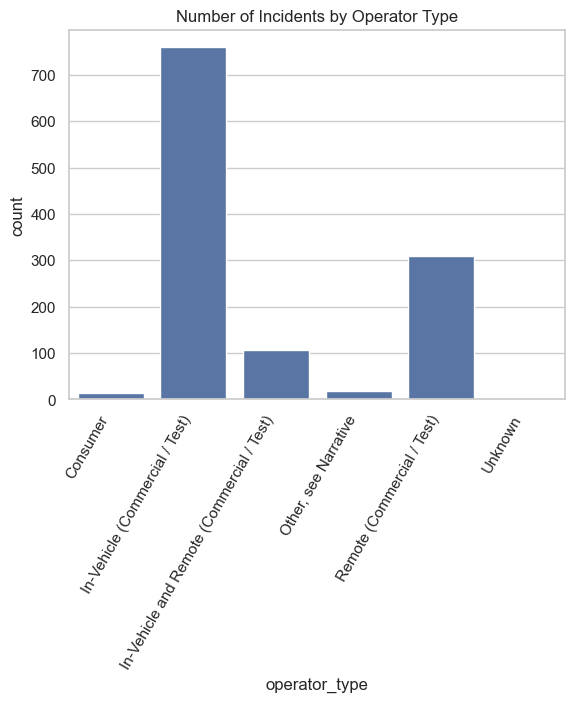

In [19]:
sns.countplot(data=df_model, x="operator_type")
plt.title("Number of Incidents by Operator Type")
plt.xticks(rotation=60, ha='right')
plt.show()

In-Vehicle (Commercial / Test) and Remote (Commercial / Test) are the operator types with the highest incident count.

In [20]:
in_vehicle_test = df_model[df_model['operator_type']=='In-Vehicle (Commercial / Test)']
remote_test = df_model[df_model['operator_type']=='Remote (Commercial / Test)']

in_vehicle_top_10 = in_vehicle_test['reporting_entity'].value_counts()
remote_test_top_10 = remote_test['reporting_entity'].value_counts()
print("In-Vehicle Testing: Testing conducted with a human operator physically present inside the vehicle.")
print(in_vehicle_top_10.head(7))
print('--------------------------')
print("Remote-Vehicle Testing: Testing conducted without a human operator inside the vehicle, often controlled or monitored remotely.")
print(remote_test_top_10.head())


In-Vehicle Testing: Testing conducted with a human operator physically present inside the vehicle.
reporting_entity
Waymo LLC                        227
Transdev Alternative Services    176
Zoox, Inc.                        98
Argo AI                           26
Ford Motor Company                24
May Mobility                      24
PACCAR Incorporated               21
Name: count, dtype: int64
--------------------------
Remote-Vehicle Testing: Testing conducted without a human operator inside the vehicle, often controlled or monitored remotely.
reporting_entity
General Motors, LLC    156
Cruise LLC             153
Ambarella                0
Robotic Research         0
NAVYA Inc.               0
Name: count, dtype: int64


In [21]:
df_model

,report_id,reporting_entity,make,model,model_year,mileage,operator_type,state_or_local_permit,ads_equipped?,automation_system_engaged,...,sv_contact_rear,sv_contact_top,sv_contact_front,sv_contact_rear_right,sv_contact_right,sv_contact_front_right,sv_contact_bottom,sv_contact_unknown,incident_month,incident_year
0,30270-10276,Waymo LLC,Jaguar,I-Pace,2021.0,102999.0,NaN,"CA PUC, CA DMV",Yes,ADS,...,,,,,,,,,2.0,2025.0
1,30270-10130,Waymo LLC,Jaguar,I-PACE,2024.0,36824.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,Y,,,,,,,,2.0,2025.0
2,30270-10274,Waymo LLC,Jaguar,I-Pace,2024.0,23633.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,,,,,,,Y,,2.0,2025.0
3,30270-10215,Waymo LLC,Jaguar,I-PACE,2021.0,147621.0,NaN,ADOT,Yes,ADS,...,,,,,,Y,,,2.0,2025.0
4,30270-10216,Waymo LLC,Jaguar,I-PACE,2024.0,26365.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,,,,,,,,,2.0,2025.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970,30270-1,Waymo LLC,Chrysler,Pacifica,2017.0,34996.0,In-Vehicle (Commercial / Test),NaN,Yes,ADS,...,,,,Y,,,,,7.0,2021.0
1971,30531-6,Transdev Alternative Services,Jaguar,I-Pace,2021.0,1232.0,"Other, see Narrative",NaN,Yes,ADS,...,Y,,,Y,,,,,7.0,2021.0
1972,30270-4,Waymo LLC,Jaguar,I-Pace,2021.0,1232.0,"Other, see Narrative",NaN,Yes,ADS,...,Y,,,Y,,,,,7.0,2021.0
1973,30531-2,Transdev Alternative Services,Chrysler,Pacifica,2017.0,34996.0,In-Vehicle (Commercial / Test),NaN,Yes,ADS,...,,,,Y,,,,,7.0,2021.0


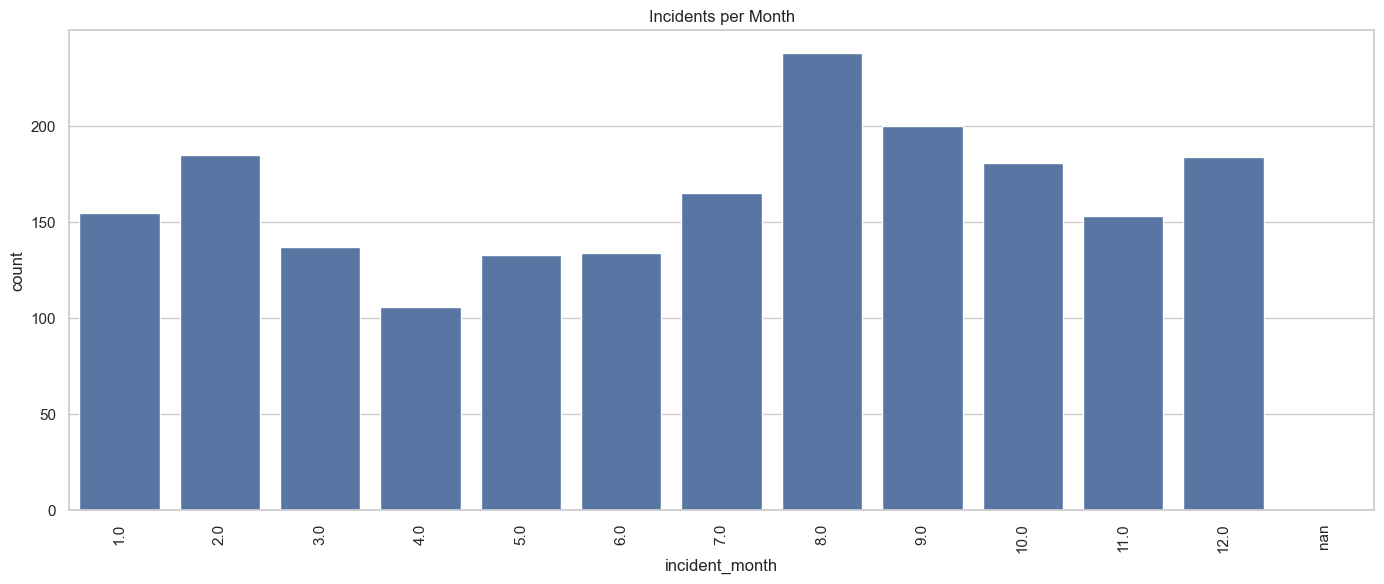

In [22]:
plt.figure(figsize=(14, 6))
sns.countplot(
    data=df_model,
    x='incident_month',
    order=sorted(df_model['incident_month'].unique())
)
plt.xticks(rotation=90)
plt.title("Incidents per Month")
plt.tight_layout()
plt.show()


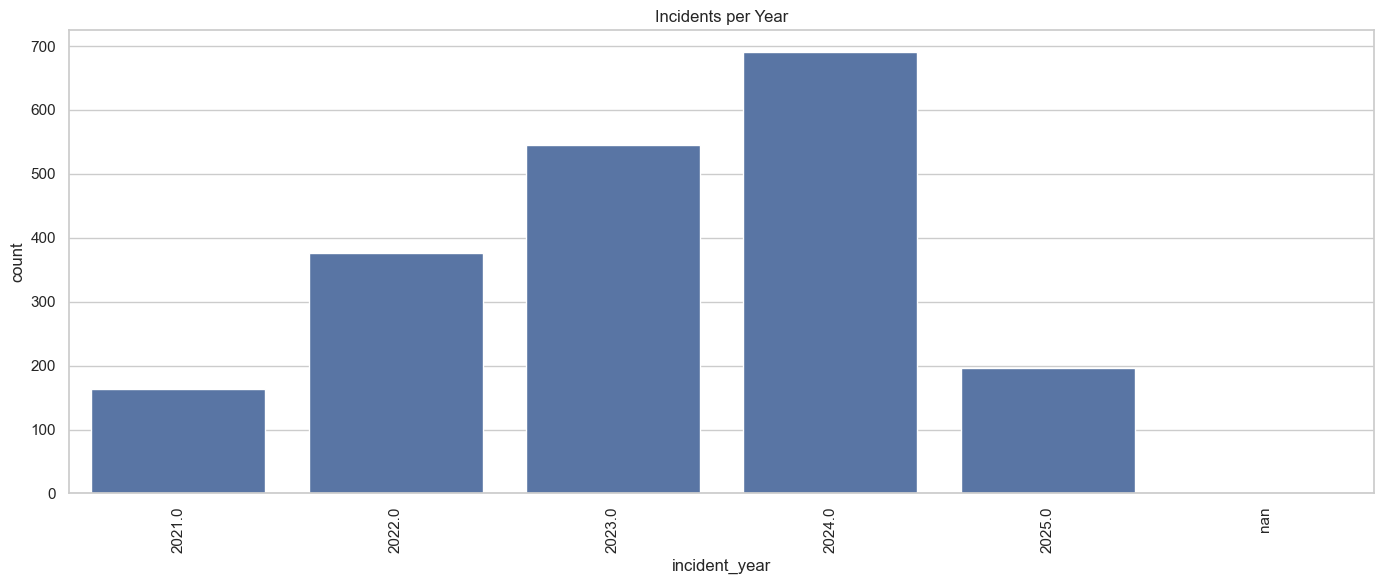

In [23]:
plt.figure(figsize=(14, 6))
sns.countplot(
    data=df_model,
    x='incident_year',
    order=sorted(df_model['incident_year'].unique())
)
plt.xticks(rotation=90)
plt.title("Incidents per Year")
plt.tight_layout()
plt.show()

Year over year there's been an uptick with indicents and we have yet to see how many incidents 2025 may result in.

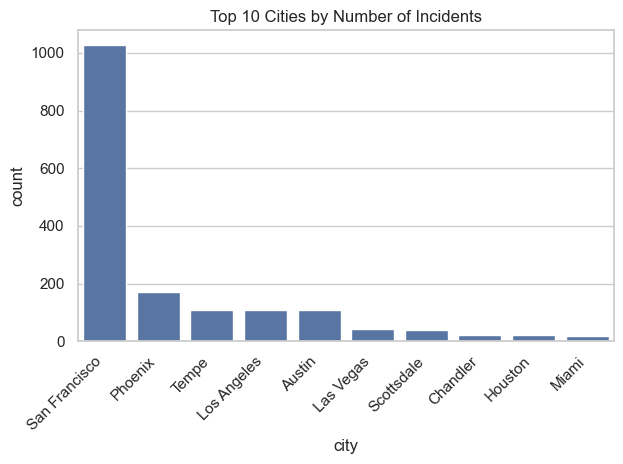

In [24]:
# Get top 10 cities by count
top_cities = df_model['city'].value_counts().nlargest(10).index

# Filter the dataframe
top_cities_df = df_model[df_model['city'].isin(top_cities)]

# Plot
sns.countplot(data=top_cities_df, x="city", order=top_cities)
plt.title("Top 10 Cities by Number of Incidents")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


San Francisco has the highest number of ADS incidents.

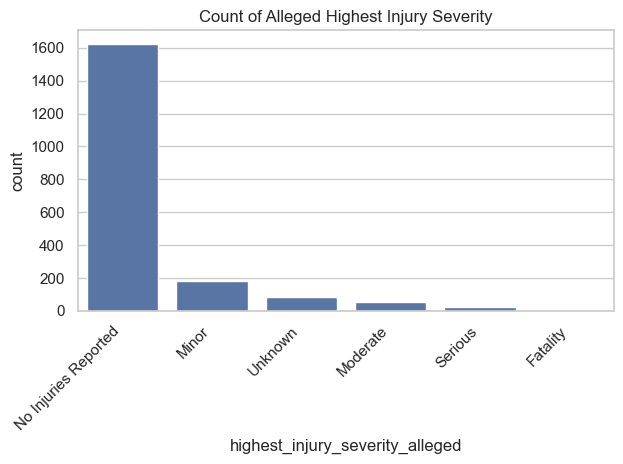

highest_injury_severity_alleged
No Injuries Reported    1624
Minor                    181
Unknown                   82
Moderate                  56
Serious                   25
Fatality                   4
Name: count, dtype: int64


In [25]:
order = df_model['highest_injury_severity_alleged'].value_counts().index
counts = df_model['highest_injury_severity_alleged'].value_counts()
sns.countplot(
    data=df_model,
    x="highest_injury_severity_alleged",
    order=order
)
plt.title("Count of Alleged Highest Injury Severity")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(counts)

Of all incidents in this data set of where reports are mandatory, around 1600 / 1975 incidents resulted in no injury. Plot is misleading, but there were 3 unique incidents of a crash resulting in a Fatality: Waymo in Janurary 1/2025 and by Cruise on 9/2023, a susidiary of GM.

In [26]:
df_model[df_model['highest_injury_severity_alleged']== 'Fatality']

,report_id,reporting_entity,make,model,model_year,mileage,operator_type,state_or_local_permit,ads_equipped?,automation_system_engaged,...,sv_contact_rear,sv_contact_top,sv_contact_front,sv_contact_rear_right,sv_contact_right,sv_contact_front_right,sv_contact_bottom,sv_contact_unknown,incident_month,incident_year
176,30270-9724,Waymo LLC,Jaguar,I-Pace,2024.0,13695.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,Y,,,Y,Y,Y,,,1.0,2025.0
187,30270-9724,Waymo LLC,Jaguar,I-Pace,2024.0,13695.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,Y,,,Y,Y,Y,,,1.0,2025.0
1021,540-6454,"General Motors, LLC",Cruise,AV,2022.0,31256.0,Remote (Commercial / Test),AZ,Yes,ADS,...,,,,,,,Y,,9.0,2023.0
1032,30412-6439,Cruise LLC,Cruise,AV,2022.0,31256.0,Remote (Commercial / Test),AZ,Yes,ADS,...,,,,,,,Y,,9.0,2023.0


For in-vehicle testing waymo has the highest number of incidents followed by Transdev Alternative Service and Zoox, Inc.

For remote-vehicle testing general motors leads the number of incidents followed by Cruise.

Text(0.5, 1.0, 'Count of Incidents by roadway_type')

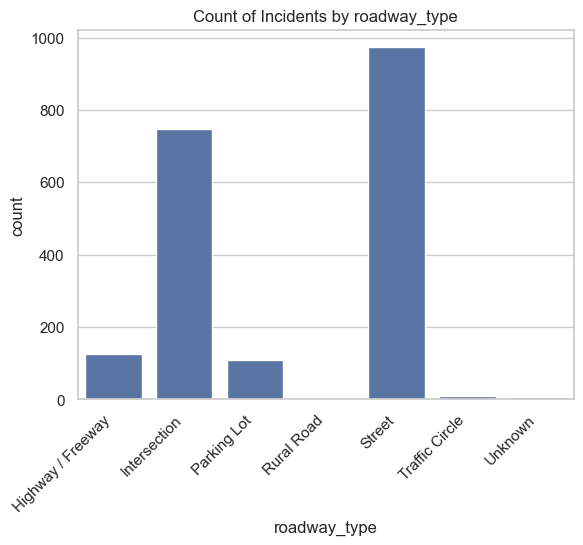

In [27]:
sns.countplot(data=df_model, x="roadway_type")
plt.xticks(rotation=45, ha='right')
plt.title("Count of Incidents by roadway_type")

In [26]:
df_model

,report_id,reporting_entity,make,model,model_year,mileage,operator_type,state_or_local_permit,ads_equipped?,automation_system_engaged,...,sv_contact_rear,sv_contact_top,sv_contact_front,sv_contact_rear_right,sv_contact_right,sv_contact_front_right,sv_contact_bottom,sv_contact_unknown,incident_month,incident_year
0,30270-10276,Waymo LLC,Jaguar,I-Pace,2021.0,102999.0,NaN,"CA PUC, CA DMV",Yes,ADS,...,,,,,,,,,2.0,2025.0
1,30270-10130,Waymo LLC,Jaguar,I-PACE,2024.0,36824.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,Y,,,,,,,,2.0,2025.0
2,30270-10274,Waymo LLC,Jaguar,I-Pace,2024.0,23633.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,,,,,,,Y,,2.0,2025.0
3,30270-10215,Waymo LLC,Jaguar,I-PACE,2021.0,147621.0,NaN,ADOT,Yes,ADS,...,,,,,,Y,,,2.0,2025.0
4,30270-10216,Waymo LLC,Jaguar,I-PACE,2024.0,26365.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,,,,,,,,,2.0,2025.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970,30270-1,Waymo LLC,Chrysler,Pacifica,2017.0,34996.0,In-Vehicle (Commercial / Test),NaN,Yes,ADS,...,,,,Y,,,,,7.0,2021.0
1971,30531-6,Transdev Alternative Services,Jaguar,I-Pace,2021.0,1232.0,"Other, see Narrative",NaN,Yes,ADS,...,Y,,,Y,,,,,7.0,2021.0
1972,30270-4,Waymo LLC,Jaguar,I-Pace,2021.0,1232.0,"Other, see Narrative",NaN,Yes,ADS,...,Y,,,Y,,,,,7.0,2021.0
1973,30531-2,Transdev Alternative Services,Chrysler,Pacifica,2017.0,34996.0,In-Vehicle (Commercial / Test),NaN,Yes,ADS,...,,,,Y,,,,,7.0,2021.0


#### Preprocessing: modeling

We are going to now be further preprocessing to set up the data for modeling our classifier. We are now going to encode, split, train and cross validate

In [28]:
df_model['highest_injury_severity_alleged'].value_counts(dropna=False)

highest_injury_severity_alleged
No Injuries Reported    1624
Minor                    181
Unknown                   82
Moderate                  56
Serious                   25
Fatality                   4
NaN                        3
Name: count, dtype: int64

In [29]:
# preprocess response variable into injury vs No injury

df_model['highest_injury_severity_alleged'].unique()
df_model['highest_injury_severity_alleged'].value_counts(dropna=False)

df_model['injury_binary'] = df_model['highest_injury_severity_alleged'].map(
    lambda x: 0 if x=="No Injuries Reported" else 1
)
df_model

,report_id,reporting_entity,make,model,model_year,mileage,operator_type,state_or_local_permit,ads_equipped?,automation_system_engaged,...,sv_contact_top,sv_contact_front,sv_contact_rear_right,sv_contact_right,sv_contact_front_right,sv_contact_bottom,sv_contact_unknown,incident_month,incident_year,injury_binary
0,30270-10276,Waymo LLC,Jaguar,I-Pace,2021.0,102999.0,NaN,"CA PUC, CA DMV",Yes,ADS,...,,,,,,,,2.0,2025.0,0
1,30270-10130,Waymo LLC,Jaguar,I-PACE,2024.0,36824.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,,,,,,,,2.0,2025.0,0
2,30270-10274,Waymo LLC,Jaguar,I-Pace,2024.0,23633.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,,,,,,Y,,2.0,2025.0,0
3,30270-10215,Waymo LLC,Jaguar,I-PACE,2021.0,147621.0,NaN,ADOT,Yes,ADS,...,,,,,Y,,,2.0,2025.0,0
4,30270-10216,Waymo LLC,Jaguar,I-PACE,2024.0,26365.0,NaN,"CA DMV, CA PUC",Yes,ADS,...,,,,,,,,2.0,2025.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970,30270-1,Waymo LLC,Chrysler,Pacifica,2017.0,34996.0,In-Vehicle (Commercial / Test),NaN,Yes,ADS,...,,,Y,,,,,7.0,2021.0,0
1971,30531-6,Transdev Alternative Services,Jaguar,I-Pace,2021.0,1232.0,"Other, see Narrative",NaN,Yes,ADS,...,,,Y,,,,,7.0,2021.0,0
1972,30270-4,Waymo LLC,Jaguar,I-Pace,2021.0,1232.0,"Other, see Narrative",NaN,Yes,ADS,...,,,Y,,,,,7.0,2021.0,0
1973,30531-2,Transdev Alternative Services,Chrysler,Pacifica,2017.0,34996.0,In-Vehicle (Commercial / Test),NaN,Yes,ADS,...,,,Y,,,,,7.0,2021.0,0


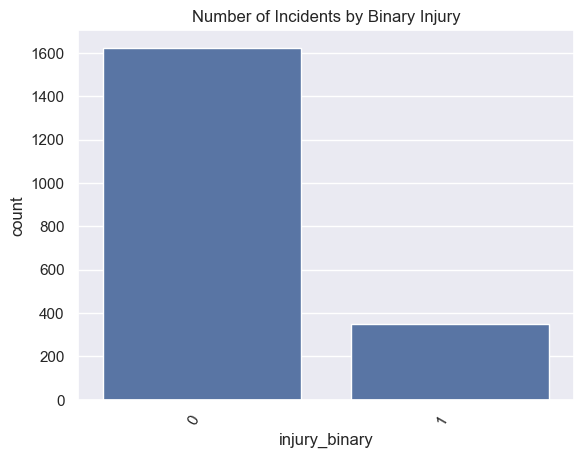

In [30]:
# drop null response values.
df_model = df_model.dropna(subset=['injury_binary'])
X = df_model.drop(columns=['injury_binary'])
y = df_model['injury_binary']

sns.countplot(data=df_model, x="injury_binary")
plt.title("Number of Incidents by Binary Injury")
plt.xticks(rotation=60, ha='right')
plt.show()

By binary encoding the incident by whether it resulted in an injury or not, there is an obvious dataset inbalance when it comes to incidents resulting in injury. There are about 1600 incidents resulting in no injury and around 350-380 incidents resulting in injury.

In [31]:
# dropped variable that we extracted response variable from
df_model = df_model.drop(columns = ['highest_injury_severity_alleged','report_id', 'weather_other_text'])

In [32]:
# get a list of columns that have categorical values to one hot encode
# convert Y/N cols to binary
one_hot_encoding_cols = [
    "reporting_entity", "make", "model", "operator_type", "state_or_local_permit", "automation_system_engaged", "city", "state", "roadway_type", "roadway_surface",
    "roadway_description","crash_with", "cp_pre_crash_movement", "sv_pre_crash_movement",
    "sv_all_passengers_belted", "lighting"
]
numeric_features = [
    'incident_month',
    'incident_year',
    'mileage',
    'model_year',
    'posted_speed_limit_mph',
    'sv_precrash_speed_mph'
]
response = ['injury_binary']

binary_cols = set(df_model.columns) - set(one_hot_encoding_cols) - set(numeric_features) - set(response)

In [33]:
# normalize values: convert everything to lowercase strings
# convert y/Yes/N/Nan to 1 and 0
df_model[list(binary_cols)] = (
    df_model[list(binary_cols)]
    .apply(lambda col: col.astype(str).str.strip().str.lower().isin(['y', 'yes']).astype(int))
)

#### Classification


In [34]:
# build ColumnTransformer to transform the categorical variables

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown='ignore'))
])

binary_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("cat", categorical_pipeline, one_hot_encoding_cols),
    ("bin_num", binary_numeric_pipeline, list(binary_cols) + numeric_features)
])


In [35]:
# build pipeline with logistic regression
# cross validate using 5 folds and iterating over 1000 times
# use the solver = 'liblinear' works with l1 and l2 penalty with a single class

# Since the data set is imbalanced due to the number of non injury incidents, we have to balance each class weight.
from sklearn.linear_model import LogisticRegressionCV

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegressionCV(cv=5, scoring='accuracy',
                                        max_iter=1000, random_state=42, solver='liblinear',class_weight='balanced'))
])

In [36]:
# split data: train and test the model using logistic regression
# warning might occur due to the test dataset having null categorical inputs where the training set
#   had inputs.
from sklearn.metrics import classification_report

X = df_model.drop(columns=['injury_binary'])
y = df_model['injury_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90       305
           1       0.64      0.86      0.73        90

    accuracy                           0.86       395
   macro avg       0.79      0.86      0.82       395
weighted avg       0.88      0.86      0.86       395



/Users/brandonrhee/PycharmProjects/autonomous_vehicle_incidents/.venv/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 4, 6, 8, 13] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


#### Model Diagnosis

Our logistic regression model has an overall accuracy of 82%. This indicates a strong general performance. However, since the data set is imbalanced and our primary interest lies in correctly identifying injury-prone incidents, accuracy alone isn't sufficient for model evaluation.

Precision (positive predictive value) class (0): 95%, class (1): 53%.

Recall (True positive rate) class(0): 82%, class(1): 81%.

If we just evaluated precision by these metrics, we would have poor model. However, looking at recall of all the injury-prone incidents, the model identified 81% correctly. In this instance, recall is a stronger indicator of model evaluation since we're trying to attribute why a ADS might injure a human